In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
#%load_ext cudf.pandas
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate
)
%matplotlib inline
plt.style.use('seaborn-v0_8')
plt.rc('figure', figsize=(10,6), dpi=180)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=15, titlepad=10)
plt.rc('animation', html='html5')

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_10k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_2k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_100k.csv
/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #cf1323, #000043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #00ffc8;
    text-shadow: 0 0 12px rgba(0,255,200,0.5);
  ">
    <span style="color:#7aa6ec5;">Load</span> <span style="color:#7aa6ec5;">the</span> <span style="color:#7aa6ec5;">DataFrame</span>
  </h1>
</div>

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv', index_col='id')

In [ ]:
train.shape

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #cf1223, #000043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 200, 0.25);
">
  <h1 style="
    font-size: 28x;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #00ffc8;
    text-shadow: 0 0 12px rgba(0,255,200,0.5);
  ">
    <span style="color:#7aa6ec5;">Exploratory</span> <span style="color:#7aa6ec2;">Data</span> <span style="color:#7aa6ec1;">Analysis</span>
  </h1>
</div>

In [ ]:
train.head()

In [ ]:
train.dtypes

In [5]:
train.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [4]:
features = ['road_type', 'num_lanes', 'curv_bin', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents']

target = 'accident_risk'

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #cf1223, #000043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 200, 0.25);
">
  <h1 style="
    font-size: 28x;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #00ffc8;
    text-shadow: 0 0 12px rgba(0,255,200,0.5);
  ">
    <span style="color:#7aa6ec5;">Feature</span> <span style="color:#7aa6ec2;">Engineering</span>
  </h1>
</div>

## Feature Binning

In [6]:
labels = ['low', 'medium', 'high', 'extreme high']
train['curv_bin'] = pd.qcut(train['curvature'], q=4, labels=labels)
test['curv_bin'] = pd.qcut(test['curvature'], q=4, labels=labels)

## Creating base risk feature based on domain knowledge

In [7]:
def risk(df):
    base_risk = (0.4 * df['curvature'] +
                 0.2 * (df['lighting'] == 'night').astype(int) +
                 0.1 * (df["weather"] != "clear").astype(int) +
                 0.2 * (df["speed_limit"] >= 60).astype(int) +
                 0.1 * (np.array(df["num_reported_accidents"] > 4).astype(int)
    ))
                 
    noise = np.random.normal(0, 0.05, df.shape[0])
    risk_score = np.clip(base_risk + noise, 0, 1)
    df["simulated_risk"] = np.round(risk_score, 2)

    return df

In [8]:
train = risk(train)
test = risk(test)

Key idea for creating the <code>simulated_risk</code> feature is that I have created <code>base_risk</code> variable based on weighted proportion of factors that contributes towards accident risk. Added some noise to simulate to real-world scenario and clipped the values between 0 and 1.

In [9]:
train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,curv_bin,simulated_risk
id,,,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,low,0.01
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,extreme high,0.43
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,high,0.43
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,low,0.09
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,high,0.45


In [ ]:
train.dtypes

In [10]:
num_cols = test.select_dtypes(include='float').columns.to_list()
cat_cols = test.select_dtypes(include=['object', 'category']).columns.to_list()

## Categorical Encoding

Converting categorical columns into numerical codes, best for linear models

In [11]:
for c in cat_cols:
    train[c] = pd.Categorical(train[c]).codes
    test[c] = pd.Categorical(test[c]).codes

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #cf1223, #000043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 200, 0.25);
">
  <h1 style="
    font-size: 28x;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #00ffc8;
    text-shadow: 0 0 12px rgba(0,255,200,0.5);
  ">
    <span style="color:#7aa6ec5;">Preparing the data for modeling</span> 
  </h1>
</div>

## Splitting the data into training and testing sets


In [12]:
from sklearn.preprocessing import StandardScaler

I have scaled the dataset using <code>StandardScaler</code> as it prevents NaNs which causes due to widly scaled features.

In [13]:
X = train.copy()
y = X.pop('accident_risk')

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_valid_scaled = scaler.transform(X_valid)


## SDGRegressor from scratch

In [14]:
class SGDRegressor:
    """
    Stochastic Gradient Descent Regressor (from scratch)
    """
    def __init__(self, learning_rate=0.01, epochs=50, batch_size=1, reg=None, reg_param=0.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg = reg
        self.reg_param = reg_param
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Convert to numpy arrays (safe for pandas DataFrames from Kaggle)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)  # ensure 1D

        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0.0

        for _ in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # Forward pass
                pred = np.dot(X_batch, self.weights) + self.bias

                # Error = pred - y  (standard convention for MSE gradient)
                error = pred - y_batch

                # Gradients for Mean Squared Error (including the factor of 2)
                gradient_w = (2 / self.batch_size) * np.dot(X_batch.T, error)
                gradient_b = (2 / self.batch_size) * np.sum(error)

                if self.reg == 'l2':
                    gradient_w += 2 * self.reg_param * self.weights
                elif self.reg == 'l1':
                    gradient_w += self.reg_param * np.sign(self.weights)

                # SGD update (this is the exact rule from our earlier lesson!)
                self.weights -= self.learning_rate * gradient_w
                self.bias -= self.learning_rate * gradient_b

        return self   

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.dot(X, self.weights) + self.bias

    def compute_loss(self, X, y):
        """Returns RMSE (standard for Kaggle regression)."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        pred = self.predict(X)
        mse = np.mean((y - pred) ** 2)
        reg_loss = 0.0
        if self.reg == 'l1':
            reg_loss = self.reg_param * np.sum(np.abs(self.weights))
        elif self.reg == 'l2':
            reg_loss = self.reg_param * np.sum(self.weights ** 2)
        return np.sqrt(mse + reg_loss)   # clean RMSE + reg term

    def get_weights(self):
        return self.weights

In [15]:
sgd = SGDRegressor(learning_rate=0.01, batch_size=32, epochs=30, reg='l2', reg_param=0.01).fit(X_train_scaled, y_train)

In [16]:
yhat = sgd.predict(X_valid)
print("Any NaN in predictions?", np.any(np.isnan(yhat)))
print("Any inf in predictions?", np.any(np.isinf(yhat)))

Any NaN in predictions? False
Any inf in predictions? False


In [17]:
mae = mean_absolute_error(y_valid, yhat)
mse = mean_squared_error(y_valid, yhat)
rmse = np.sqrt(mean_squared_error(y_valid, yhat))
r2score = r2_score(y_valid, yhat)
explained_var = explained_variance_score(y_valid, yhat)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2score:.4f}")
print(f'Explained Variance Score: {explained_var:.4f}')

Mean Absolute Error (MAE): 1.4952
Mean Squared Error (MSE): 2.4111
Root Mean Squared Error (RMSE): 1.5528
R² Score: -86.2040
Explained Variance Score: -5.3455


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #cf1223, #000043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 200, 0.25);
">
  <h1 style="
    font-size: 28x;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #00ffc8;
    text-shadow: 0 0 12px rgba(0,255,200,0.5);
  ">
    <span style="color:#7aa6ec5;">Optuna Study</span> 
  </h1>
</div>

### Conducting optuna study for find the optima hyperparameter configurations for our model:
- setting parameters
- use SGDRegressor as the predictive model
- Extract parameter importance

In [18]:
from sklearn.pipeline import make_pipeline

In [19]:
def objective(trial):

    reg_choice = trial.suggest_categorical('reg', ['l1', 'l2'])
    
    reg = reg_choice
    reg_param = trial.suggest_float('reg_param', 1e-5, 10.0, log=True)
        
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.0001, 0.3, log=True),
        'epochs': trial.suggest_int('epochs', 5, 100),
        'batch_size': trial.suggest_int('batch_size', 16, 256, step=8),
        'reg': reg,
        'reg_param': reg_param,
    }
    
    sgd = SGDRegressor(**params)
    model = make_pipeline(StandardScaler(), sgd)

    cv = KFold(n_splits=5, shuffle=True, random_state=2)
    score = -1 * cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

study = optuna.create_study(direction='minimize', study_name='SGD-Optimization')
study.optimize(objective, n_trials=10, show_progress_bar=True)

[I 2026-03-08 09:47:10,142] A new study created in memory with name: SGD-Optimization


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-08 09:47:21,513] Trial 0 finished with value: 0.08761417969241916 and parameters: {'reg': 'l1', 'reg_param': 0.08354384530795986, 'learning_rate': 0.00036460708926630206, 'epochs': 26, 'batch_size': 160}. Best is trial 0 with value: 0.08761417969241916.
[I 2026-03-08 09:47:29,660] Trial 1 finished with value: 0.07387820687169118 and parameters: {'reg': 'l1', 'reg_param': 0.002010663819729114, 'learning_rate': 0.2574013180040322, 'epochs': 16, 'batch_size': 72}. Best is trial 1 with value: 0.07387820687169118.
[I 2026-03-08 09:47:44,150] Trial 2 finished with value: 0.07196470671284434 and parameters: {'reg': 'l2', 'reg_param': 0.0003595157579486935, 'learning_rate': 0.0018747443022847084, 'epochs': 18, 'batch_size': 32}. Best is trial 2 with value: 0.07196470671284434.
[I 2026-03-08 09:47:48,390] Trial 3 finished with value: 0.07502044164204758 and parameters: {'reg': 'l1', 'reg_param': 0.015426230315412855, 'learning_rate': 0.03793888517196973, 'epochs': 11, 'batch_size': 1

In [22]:
best_params = study.best_params.copy()

final_model = SGDRegressor(**best_params)
final_model.fit(X_train_scaled, y_train)  

y_pred = final_model.predict(X_valid_scaled)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
r2score = r2_score(y_valid, y_pred)
explained_var = explained_variance_score(y_valid, y_pred)

print(f"Final Validation RMSE: {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2score:.4f}")
print(f'Explained Variance Score: {explained_var:.4f}')

Final Validation RMSE: 0.0720
Mean Absolute Error (MAE): 0.0566
Mean Squared Error (MSE): 0.0052
Root Mean Squared Error (RMSE): 0.0720
R² Score: 0.8126
Explained Variance Score: 0.8126


You can see from the results above that our model with the good hyperparameters have significantly performed then our base model with random parameters.

### Plot Actual vs Predicted values

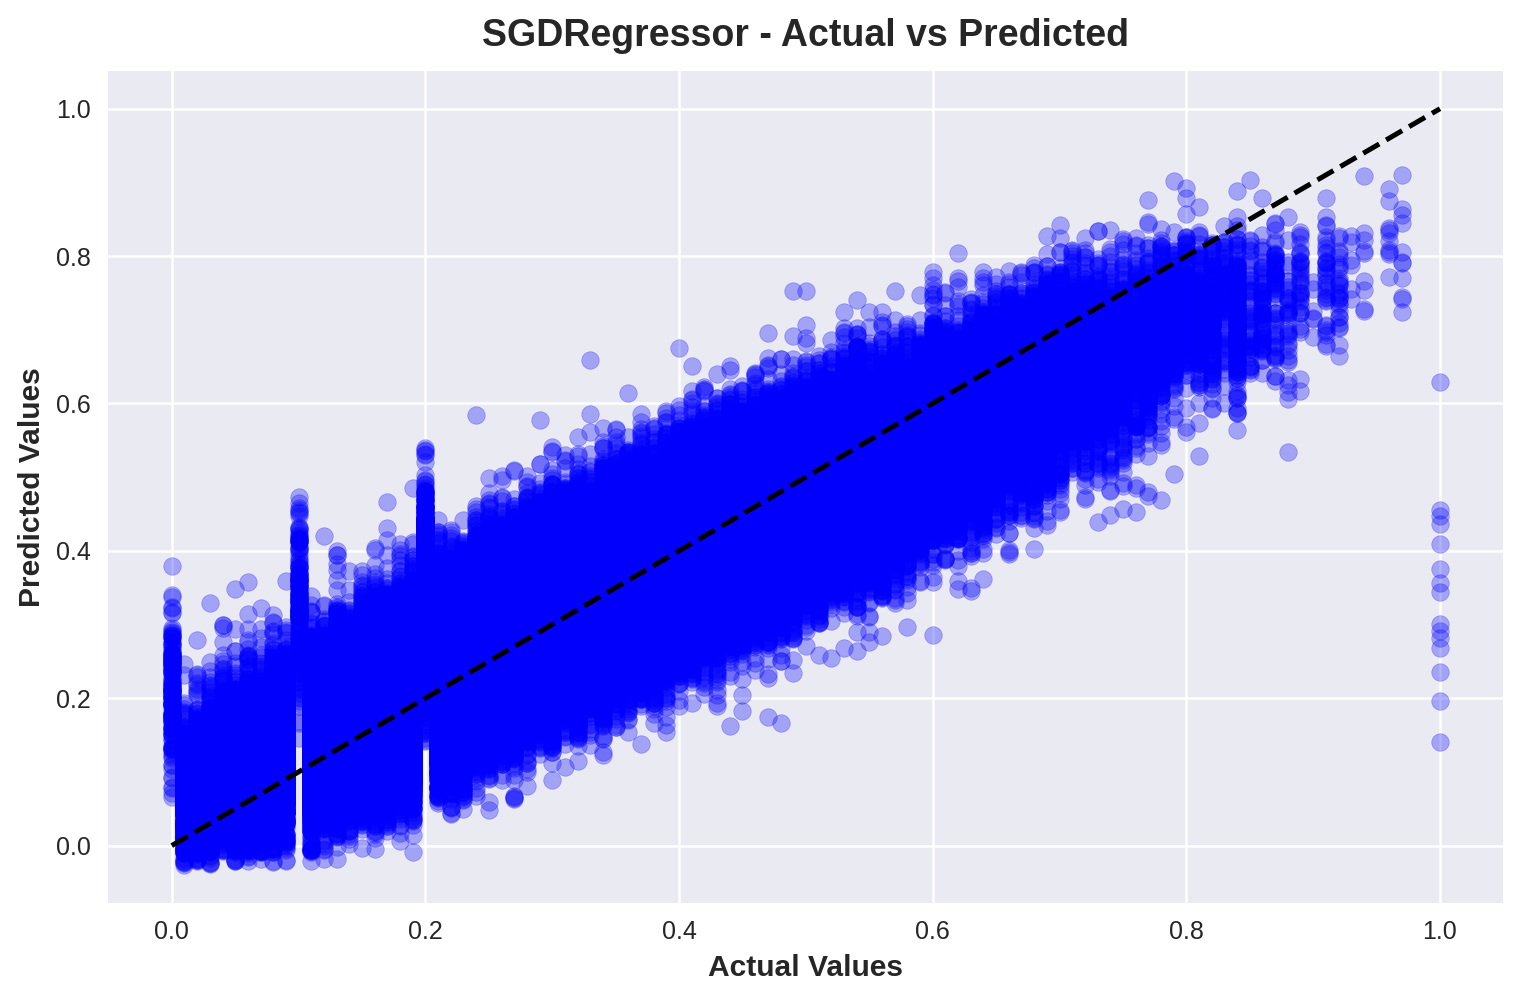

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(y_valid, y_pred, alpha=0.3, color='blue')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SGDRegressor - Actual vs Predicted")
plt.show()